In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve

import tensorflow as tf
from tensorflow import keras

**Preprocessing Data**

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
print("Shape: ", df.shape)
#df.shape is used to define the dataset shape

Shape:  (284807, 31)


In [4]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

**EDA**


Exploratory Data Analysis (EDA) is the process of analyzing, summarizing, and visualizing datasets to understand their structure, patterns, and anomalies. It detects outliers, handles missing values, and identifies key feature


In [5]:
#Detect Class Imbalance

class_counts = df["Class"].value_counts()
print("\nClass counts\n", class_counts)
print("\nClass %:\n", df["Class"].value_counts(normalize=True))


Class counts
 Class
0    284315
1       492
Name: count, dtype: int64

Class %:
 Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


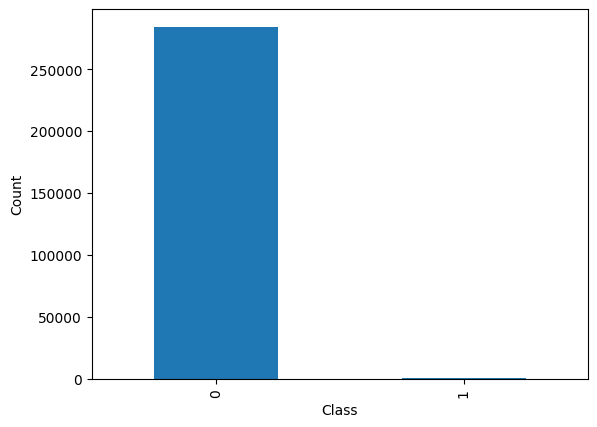

In [6]:
#Bar Chart
plt.figure()
class_counts.plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Based on the Bar Chart, we can see that there is an imbalance in the data

In [7]:
#Detect Missing Value
missing_value = df.isna().sum()
print("\nMissing Values:\n", missing_value.sort_values(ascending=False).head(10)) # Print Top 10 Missing Values


Missing Values:
 Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
dtype: int64


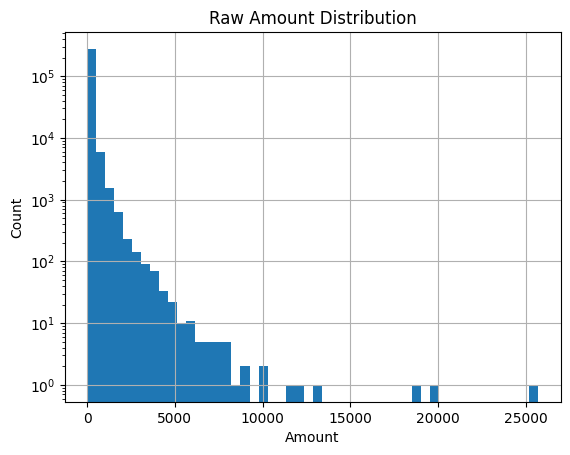

In [8]:
#Amount Distribution (skew)
plt.figure()
df["Amount"].hist(bins=50)
plt.title("Raw Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.yscale("log") #Make the skew visible
plt.show()

**Split the Dataset into X and Y**

In [9]:
y = df["Class"].astype(int).values #Label which tell us it's Fraud or not
x = df.drop(columns=["Class"]).copy() #Hold all the feature column where model allowed to learn from

**Scaling Time and Amount**

In [10]:
scaler = StandardScaler()
x[["Time", "Amount"]] = scaler.fit_transform(x[["Time", "Amount"]])

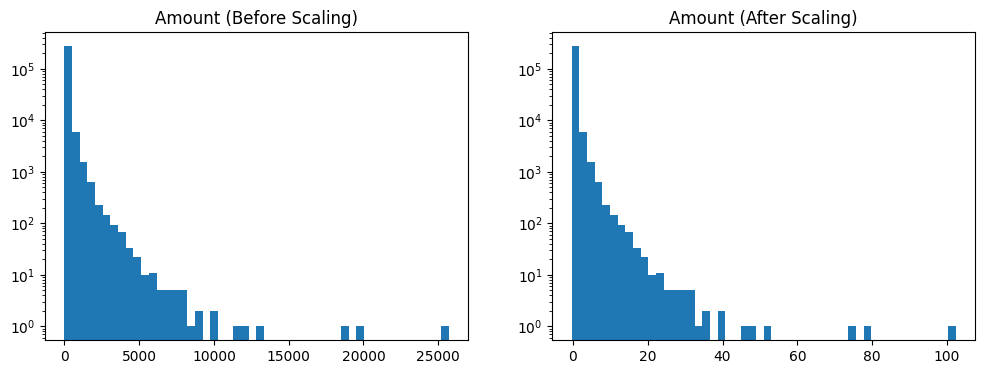

In [11]:
#Scaling doesn't change shape, just units
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["Amount"], bins=50)
axes[0].set_title("Amount (Before Scaling)")
axes[0].set_yscale("log")

axes[1].hist(x["Amount"], bins=50)
axes[1].set_title("Amount (After Scaling)")
axes[1].set_yscale("log")

plt.show()

In [12]:
#Convert to numpy for Tensorflow
x = x.values.astype(np.float32)

**Split the Dataset into Train and Test Set**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

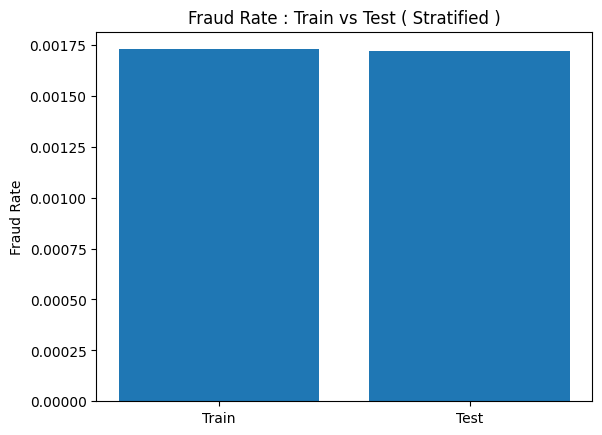

In [14]:
# Visual : fraud rate tsyas the same or similiar between train and test

train_rate = y_train.mean()
test_rate = y_test.mean()

plt.figure()
plt.bar(["Train", "Test"], [train_rate, test_rate])
plt.title("Fraud Rate : Train vs Test ( Stratified )")
plt.ylabel("Fraud Rate")
plt.show()

**Class Weight for Imbalance**


Class Weights:
 {0: 1.0, 1: np.float64(577.2868020304569)}

Train Fraud Rate :  0.001729245759178389


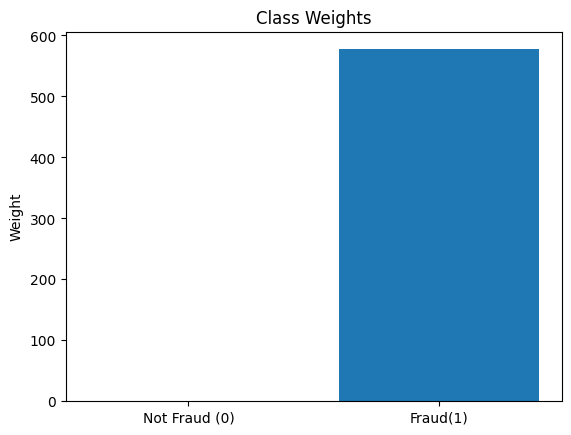

In [15]:
negative, positive = np.bincount(y_train)
class_weight = {0: 1.0, 1: negative / max(positive, 1)} # Avoid division by zero
print("\nClass Weights:\n", class_weight)
print("\nTrain Fraud Rate : ", positive / ( negative + positive ))

plt.figure()
plt.bar(["Not Fraud (0)", "Fraud(1)"], [class_weight[0], class_weight[1]])
plt.title("Class Weights")
plt.ylabel("Weight")
plt.show()

**Build Neural Network ( Simple MLP )**

In [16]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)